# **Australian Beer Production — Descriptive & Inferential Analysis**
Submitted by: **`Group 3`** <br>
Members: <br>
`Llesis, Hannah`, `Bitco, Yvonne`, `Sevilla, Emmanuel `, `Gaca, Karl`, `Tion, Cristobal`, `Ruiz, Ross Jervin `


# Introduction


## **1. Background**

Australian beer production can vary across different periods, with changes in production levels and recurring patterns that can be observed in the data.

> **But what can the Australian beer production data tell us about its patterns and its relationship with time?**

The dataset used in this study, **`ausbeer.csv`**, contains quarterly Australian beer production data from **1956 Q1 to 2010 Q2**, with a total of **218 observations**. It contains two variables: **`index`**, which represents the quarter and year, and **`value`**, which represents the amount of beer produced.

This study uses **descriptive and inferential analysis** to examine the dataset. Descriptive analysis summarizes the distribution, variation, and patterns of beer production, while inferential analysis examines the relationship between **time and beer production** using linear regression. The analysis assumes that the observations are correctly ordered chronologically and that the recorded production values accurately represent their corresponding quarters.


## **Import Libraries**

The following Python libraries are used for data manipulation, visualization, statistical analysis, linear regression, and regression diagnostics.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", None)


## **2. Dataset Introduction**

The dataset used in this study is **`ausbeer.csv`**, which contains quarterly Australian beer production observations.

The dataset covers **1956 Q1 to 2010 Q2**, providing **218 quarterly observations**. Each observation contains a quarter label and its corresponding beer production value.

For this analysis, we examine the dataset to determine:

- how production changes over the long term;
- whether production has a repeating quarterly pattern;
- whether the series contains changes in its trend;
- and whether a simple linear regression can adequately describe the time series.

### **2.1 Load the Dataset**

The dataset used for this activity is ausbeer.csv, which contains quarterly Australian beer production data. Before performing the analysis, the dataset is loaded and its structure is examined.

In [ ]:
df = pd.read_csv("ausbeer.csv")
print(df.shape)
df.head(10)


(218, 2)


,index,value
0,1956 Q1,284
1,1956 Q2,213
2,1956 Q3,227
3,1956 Q4,308
4,1957 Q1,262
5,1957 Q2,228
6,1957 Q3,236
7,1957 Q4,320
8,1958 Q1,272
9,1958 Q2,233


In [ ]:
df.info()
print()
print("Missing values per column:")
print(df.isna().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 218 entries, 0 to 217
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   index   218 non-null    object
 1   value   218 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 3.5+ KB

Missing values per column:
index    0
value    0
dtype: int64


### **2.2 Data Preparation**
The original quarter labels were separated into year and quarter variables. A date variable and a numeric time index were also created. The production column was renamed from value to production for easier interpretation.

In [ ]:
# Parse the quarter label ("1956 Q1") into a proper datetime + numeric time index
df[['year', 'quarter']] = df['index'].str.extract(r'(\d{4}) Q(\d)').astype(int)
df['date'] = pd.to_datetime(dict(year=df['year'], month=(df['quarter'] - 1) * 3 + 1, day=1))
df['t'] = np.arange(len(df))  # numeric time index for regression
df = df.rename(columns={'value': 'production'})
df[['index', 'date', 'year', 'quarter', 't', 'production']].head()


,index,date,year,quarter,t,production
0,1956 Q1,1956-01-01,1956,1,0,284
1,1956 Q2,1956-04-01,1956,2,1,213
2,1956 Q3,1956-07-01,1956,3,2,227
3,1956 Q4,1956-10-01,1956,4,3,308
4,1957 Q1,1957-01-01,1957,1,4,262


### Observations & Assumptions

* The dataset contains **218 quarterly observations** of Australian beer production from **1956 Q1 to 2010 Q2**.
* It has **two variables**: `index`, which represents the quarter and year, and `value`, which represents beer production.
* There are **no missing values** in the dataset.
* The observations are arranged chronologically, with **one observation per quarter**.
* We assume that the recorded production values are accurate and measured consistently throughout the dataset.
* Since the data is recorded over time, production in one quarter may be related to production in previous quarters.


## **3. Descriptive Analysis**

### 3.1 Summary Statistics
Descriptive statistics were calculated to summarize the distribution of quarterly beer production.


In [ ]:
desc = df['production'].describe()
desc


,production
count,218.000000
mean,415.371560
std,85.880662
min,213.000000
25%,379.250000
50%,422.000000
75%,465.750000
max,599.000000


The mean production is **415.37 megalitres**, with a standard deviation of **85.88 megalitres**. Production ranges from **213 to 599 megalitres**.

In [ ]:
print(f"Skewness: {df['production'].skew():.3f}")
print(f"Kurtosis: {df['production'].kurt():.3f}")
print(f"Coefficient of variation: {df['production'].std() / df['production'].mean():.3f}")


Skewness: -0.319
Kurtosis: -0.206
Coefficient of variation: 0.207


### 3.2 Production over Time
A time-series plot was created to observe how Australian beer production changed from 1956 Q1 to 2010 Q2.

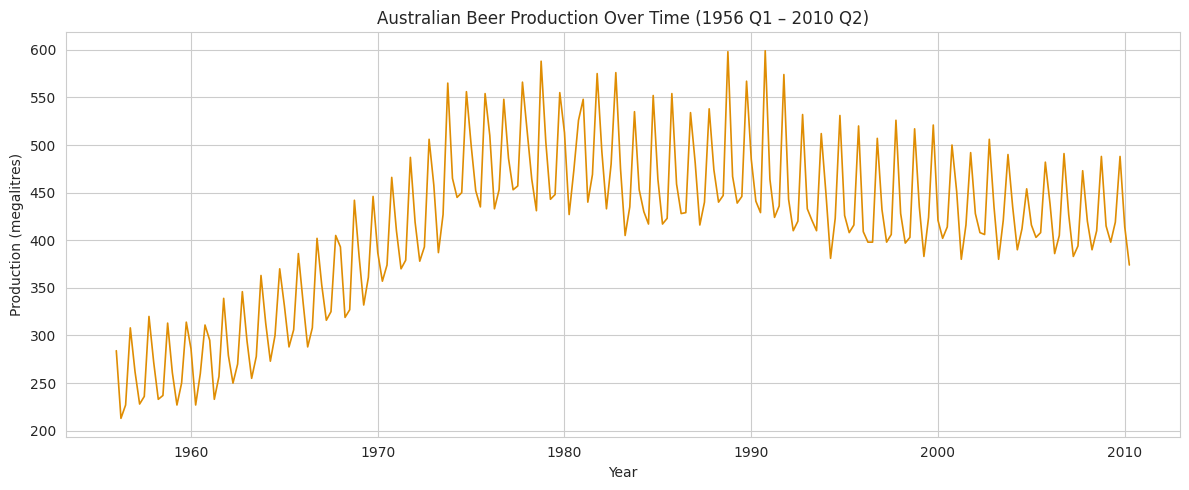

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df['date'], df['production'], color='#DF8D03', linewidth=1.2)
ax.set_title("Australian Beer Production Over Time (1956 Q1 – 2010 Q2)")
ax.set_xlabel("Year")
ax.set_ylabel("Production (megalitres)")
plt.tight_layout()
plt.show()


The series clearly shows **two regimes**: production rises fairly steadily from 1956 into the mid-1970s/1980s, then **plateaus and becomes flat-to-slightly-declining** from around the mid-1980s onward, while a strong repeating **seasonal wiggle** persists throughout. This immediately suggests that a *single straight line* is unlikely to describe the whole 54-year history well.

### 3.3 Seasonality by Quarter
Production was grouped by quarter to examine whether there are differences in production across the four quarters of the year.

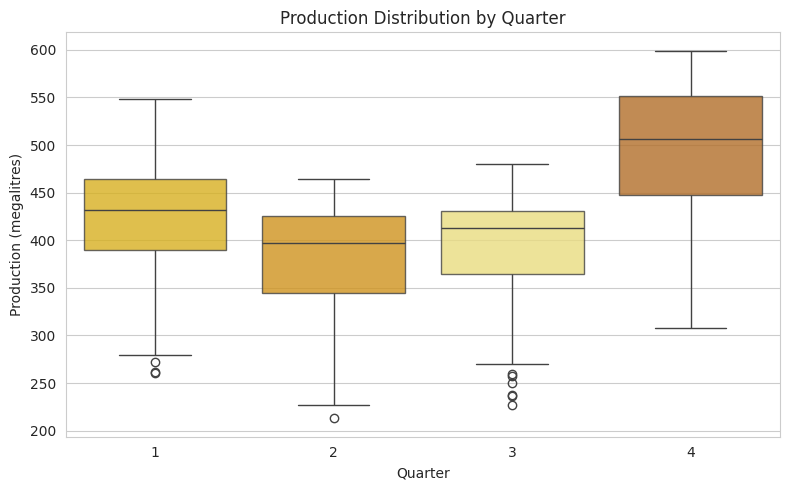

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
beer_colors = ['#F6C101', '#EC9D00', '#FAE96F', '#C96E12']
sns.boxplot(
    x='quarter',
    y='production',
    data=df,
    hue='quarter',
    palette=beer_colors,
    legend=False,
    ax=ax,
)
for patch in ax.patches:
    patch.set_alpha(0.8)
ax.set_title("Production Distribution by Quarter")
ax.set_xlabel("Quarter")
ax.set_ylabel("Production (megalitres)")
plt.tight_layout()
plt.show()


In [ ]:
quarter_means = df.groupby('quarter')['production'].agg(['mean', 'std', 'min', 'max'])
quarter_means


,mean,std,min,max
quarter,,,,
1,416.818182,73.160425,261,548
2,372.618182,71.293990,213,464
3,387.370370,69.341457,227,480
4,485.444444,84.003744,308,599


**Q4 (Oct–Dec)** consistently has the highest production and **Q2 (Apr–Jun)** the lowest — a clear, stable seasonal pattern (likely tied to summer holiday/festive demand). This is a strong signal that quarter-of-year is an important explanatory factor, separate from the long-run trend.

### 3.4 Distribution Shape
A histogram and Q-Q plot were used to examine the distribution of production values and their departure from a normal distribution.

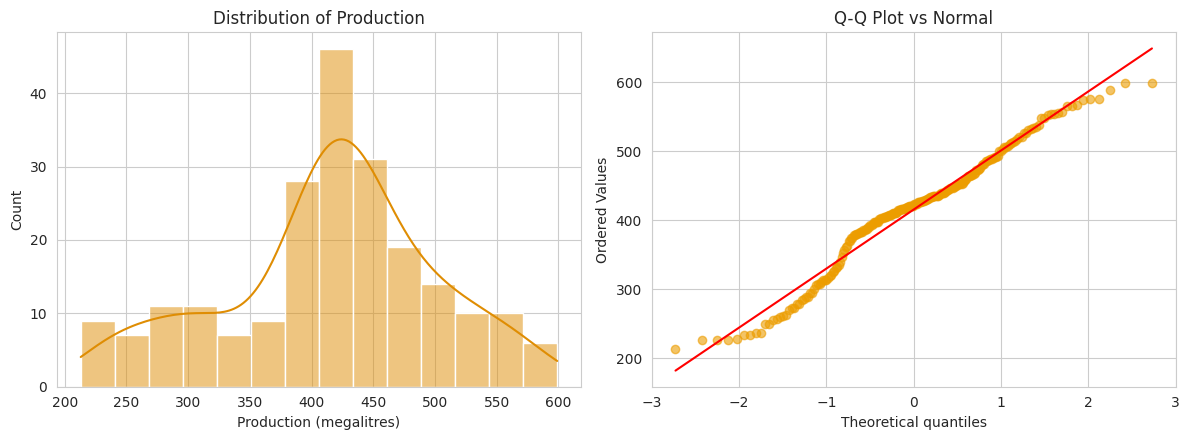

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(df['production'], kde=True, ax=axes[0], color='#DF8D03')
axes[0].set_title("Distribution of Production")
axes[0].set_xlabel("Production (megalitres)")

stats.probplot(df['production'], dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot vs Normal")
axes[1].get_lines()[0].set_color('#EC9D00')  # points
axes[1].get_lines()[1].set_color('red') # reference line
axes[1].get_lines()[0].set_alpha(0.6)
plt.tight_layout()
plt.show()


### 3.5 Trend by Decade & Year-over-year Change
Production was grouped by decade to observe changes in average production over the study period.

In [ ]:
df['decade'] = (df['year'] // 10) * 10
decade_summary = df.groupby('decade')['production'].agg(['mean', 'std', 'count'])
decade_summary


,mean,std,count
decade,,,
1950,261.5625,36.203073,16
1960,321.1250,53.944505,40
1970,461.8250,61.777055,40
1980,477.9000,54.025065,40
1990,449.2250,55.043800,40
2000,429.3750,37.408821,40
2010,394.0000,28.284271,2


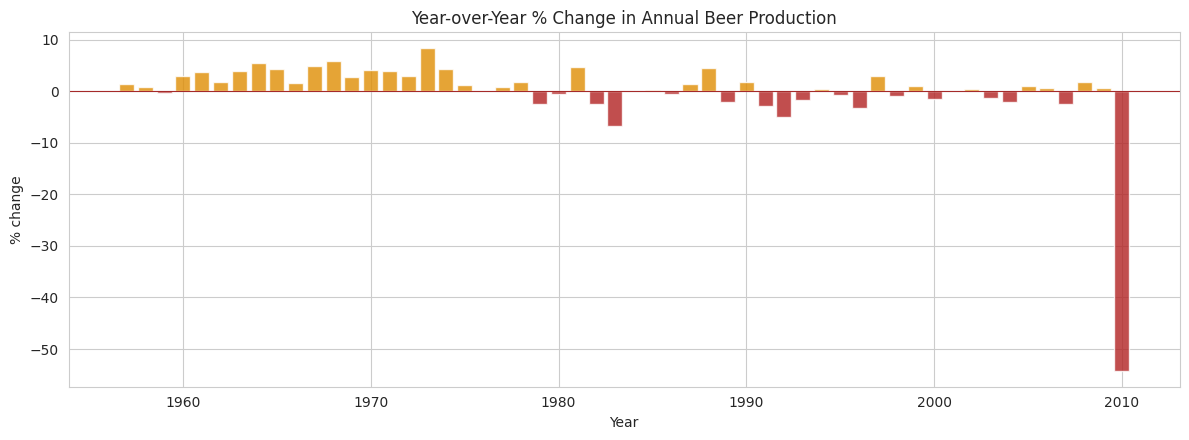

In [ ]:
annual = df.groupby('year')['production'].sum()
annual_growth = annual.pct_change() * 100

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.bar(annual_growth.index, annual_growth.values, color=np.where(annual_growth >= 0, '#DF8D03', 'firebrick'), alpha=0.8)
ax.axhline(0, color='brown', linewidth=0.8)
ax.set_title("Year-over-Year % Change in Annual Beer Production")
ax.set_ylabel("% change")
ax.set_xlabel("Year")
plt.tight_layout()
plt.show()


**Descriptive Insights:**
- Average quarterly production is around the low-to-mid 400s (megalitres) with a fairly wide spread, and the distribution is **roughly symmetric but not perfectly normal** (visible deviation from the Q-Q line at the tails), consistent with a series that mixes trend and seasonal regimes rather than random noise.
- Production **grew strongly through the 1950s–1970s**, decade means rising steadily, then **flattened and slightly declined** from the 1990s–2000s decade averages — this is a **structural break**, not a constant linear trend.
- **Seasonality is strong and stable**: Q4 > Q1 > Q3 > Q2 in typical magnitude, repeating every year.
- Year-over-year growth was consistently positive in the earlier decades and becomes much more mixed (positive and negative) after the 1980s, reflecting market maturity/saturation.


## **4. Inferential Analysis: Is Linear Regression a Good Fit?**

We test a simple linear regression of **production on time** (`t` = quarter index, 0...217) to determine whether a straight-line trend adequately describes the data. The same model is fitted using **scikit-learn** for prediction-oriented results and **statsmodels** for inferential statistics, including p-values, confidence intervals, and diagnostic measures. The regression assumptions are then evaluated to assess whether linear regression is an appropriate model for the series.

### 4.1 Scikit-learn approach
A simple linear regression was fitted using the quarter index as the predictor and beer production as the response. The model provides the estimated intercept, slope, $R^2$, RMSE, and MAE to describe the overall linear trend and its predictive error.

In [ ]:
X = df[['t']].values
y = df['production'].values

lr = LinearRegression()
lr.fit(X, y)
y_pred_sk = lr.predict(X)

print(f"Intercept: {lr.intercept_:.3f}")
print(f"Slope (per quarter): {lr.coef_[0]:.4f}")
print(f"R-squared: {r2_score(y, y_pred_sk):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y, y_pred_sk)):.3f}")
print(f"MAE: {mean_absolute_error(y, y_pred_sk):.3f}")


Intercept: 338.118
Slope (per quarter): 0.7120
R-squared: 0.2735
RMSE: 73.034
MAE: 59.487


The regression produced an intercept of **338.118** and a slope of **0.7120 per quarter**. The $R^2$ value is **0.2735**, meaning that the time index explains approximately **27.35% of the variation** in beer production. The RMSE is **73.034**, while the MAE is **59.487**.

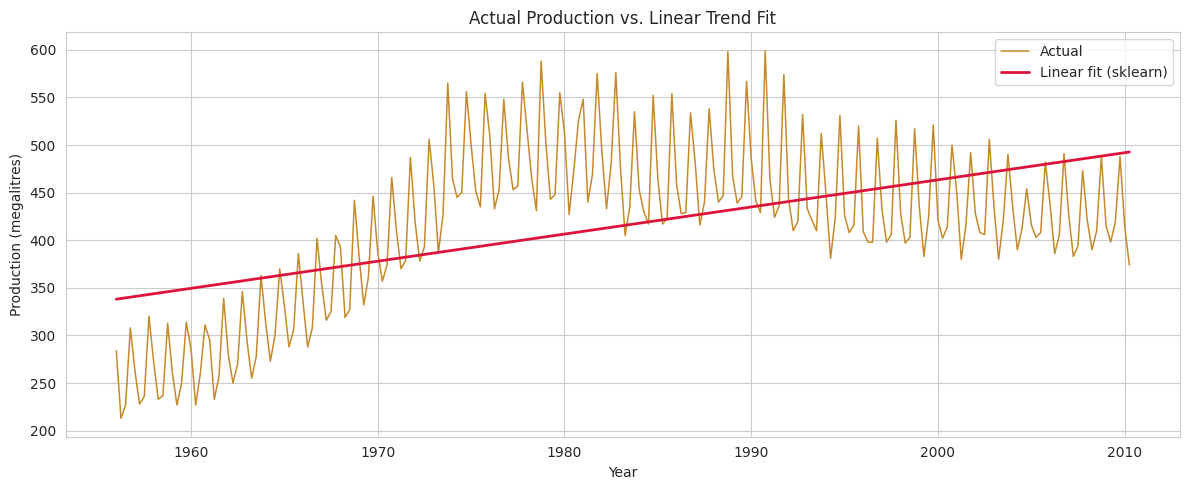

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df['date'], y, label="Actual", color='#C58A2B', linewidth=1.1)
ax.plot(df['date'], y_pred_sk, label="Linear fit (sklearn)", color='crimson', linewidth=2)
ax.set_title("Actual Production vs. Linear Trend Fit")
ax.set_xlabel("Year")
ax.set_ylabel("Production (megalitres)")
ax.legend()
plt.tight_layout()
plt.show()


The fitted linear trend captures the **general upward direction** of beer production but does not adequately capture the **repeating quarterly seasonality** or the **changes in the long-term trend**. The actual production rises strongly in the earlier period, reaches higher levels, and later flattens and declines, while the fitted line continues to increase steadily.

### 4.2 Statsmodels Approach (with full inferential statistics)
The same linear regression model was fitted using `statsmodels` to obtain the full set of inferential statistics needed to evaluate the relationship between time and Australian beer production. These include the **regression coefficients, p-values, confidence intervals, $R^2$, F-statistic, and diagnostic measures**

In [ ]:
X_sm = sm.add_constant(df['t'])
ols_model = sm.OLS(y, X_sm).fit()
print(ols_model.summary())


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.273
Model:                            OLS   Adj. R-squared:                  0.270
Method:                 Least Squares   F-statistic:                     81.30
Date:                Sun, 20 Sep 2026   Prob (F-statistic):           1.06e-16
Time:                        18:49:32   Log-Likelihood:                -1244.8
No. Observations:                 218   AIC:                             2494.
Df Residuals:                     216   BIC:                             2500.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        338.1183      9.905     34.138      0.0

The regression results show a **positive and statistically significant relationship** between time and beer production. The time coefficient is **0.712**, with a **p-value < 0.001** and a 95% confidence interval of approximately **[0.556, 0.868]**. The model has an **$R^2$ of 0.273**, indicating that time explains part of the variation in beer production.

These results confirm that beer production has a significant overall time-related trend. However, statistical significance alone does not determine whether linear regression is an appropriate model for the entire series. The regression assumptions and residual behavior are examined in the next section.

### 4.3 Checking the Assumptions of Linear Regression
Diagnostic plots and statistical tests were used to examine the assumptions of the linear regression model.

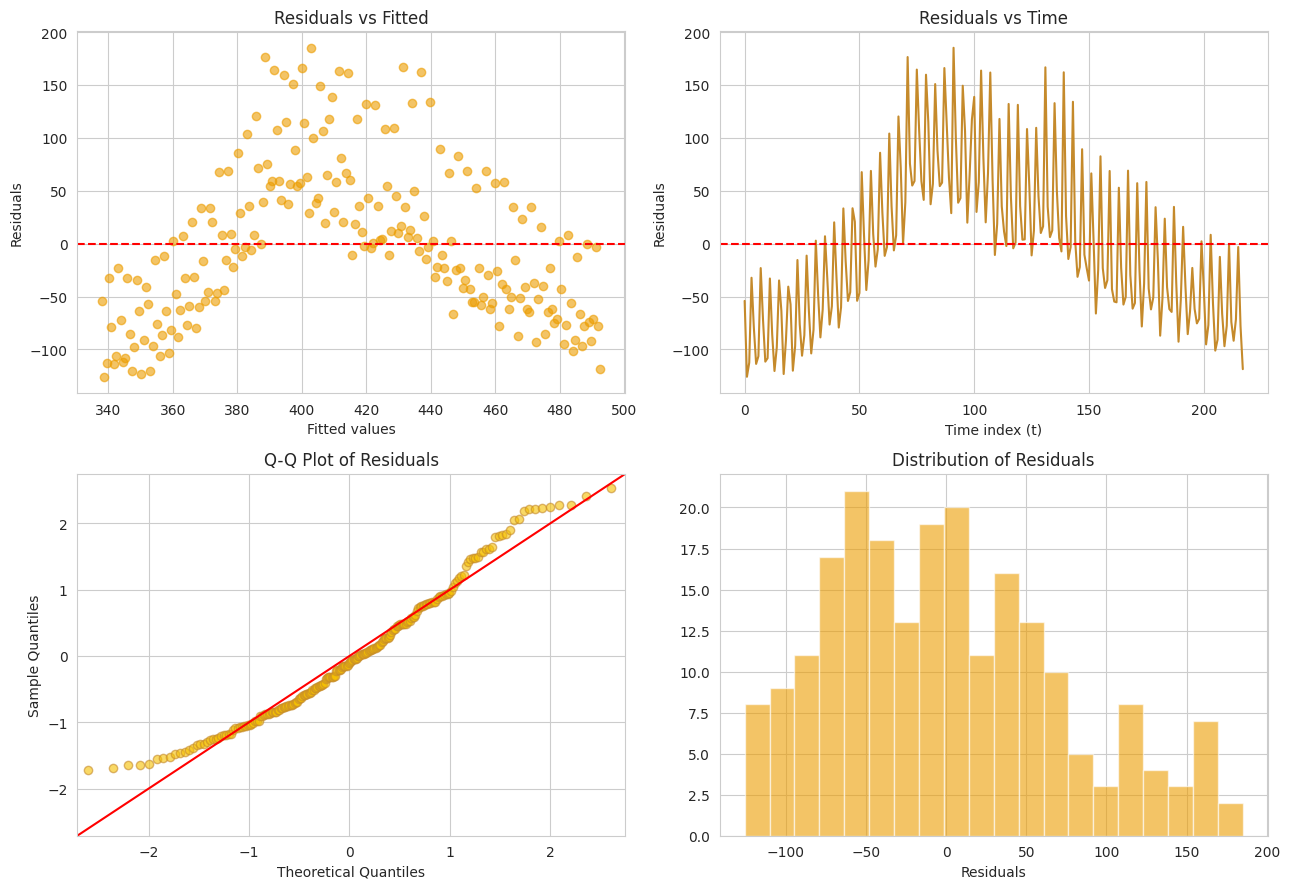

In [ ]:
residuals = ols_model.resid
fitted = ols_model.fittedvalues

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# 1. Residuals vs Fitted (linearity & homoscedasticity)
axes[0, 0].scatter(fitted, residuals, alpha=0.6, color='#EC9D00')
axes[0, 0].axhline(0, color='red', linestyle='--')
axes[0, 0].set_title("Residuals vs Fitted")
axes[0, 0].set_xlabel("Fitted values")
axes[0, 0].set_ylabel("Residuals")

# 2. Residuals vs Time (independence / autocorrelation)
axes[0, 1].plot(df['t'], residuals, color='#C58A2B')
axes[0, 1].axhline(0, color='red', linestyle='--')
axes[0, 1].set_title("Residuals vs Time")
axes[0, 1].set_xlabel("Time index (t)")
axes[0, 1].set_ylabel("Residuals")

# 3. Q-Q plot (normality)
sm.qqplot(residuals, line='45', fit=True, ax=axes[1, 0],
          markerfacecolor='#F6C101', markeredgecolor='#C58A2B', alpha=0.6)
axes[1, 0].set_title("Q-Q Plot of Residuals")

# 4. Histogram of residuals
axes[1, 1].hist(residuals, bins=20, color='#EC9D00', edgecolor='white', alpha=0.6)
axes[1, 1].set_title("Distribution of Residuals")
axes[1, 1].set_xlabel("Residuals")

plt.tight_layout()
plt.show()


In [ ]:
# Formal diagnostic tests
dw = durbin_watson(residuals)
shapiro_stat, shapiro_p = stats.shapiro(residuals)
bp_stat, bp_p, _, _ = het_breuschpagan(residuals, X_sm)

print("Assumption checks")
print(f"Durbin-Watson (independence, ~2 = none):  {dw:.3f}")
print(f"Shapiro-Wilk normality p-value:            {shapiro_p:.4g}")
print(f"Breusch-Pagan homoscedasticity p-value:     {bp_p:.4g}")
print(f"R-squared:                                  {ols_model.rsquared:.4f}")
print(f"F-statistic p-value (overall significance): {ols_model.f_pvalue:.4g}")


Assumption checks
Durbin-Watson (independence, ~2 = none):  0.855
Shapiro-Wilk normality p-value:            4.262e-05
Breusch-Pagan homoscedasticity p-value:     0.05114
R-squared:                                  0.2735
F-statistic p-value (overall significance): 1.062e-16


**Is linear regression a good fit? — Assessment**

| Assumption | Result | Verdict |
|---|---|---|
| **Linear relationship** | R² is moderate, and the residuals-versus-fitted plot shows a curved/humped pattern rather than random scatter. | ⚠️ **Violated** — the trend is not truly linear because production increases and later flattens. |
| **Independence of errors** | The Durbin–Watson statistic is far below 2, indicating strong positive autocorrelation. | ❌ **Violated** — observations are dependent over time, with recurring seasonal patterns. |
| **Homoscedasticity** | The residual spread is reasonably even overall, although some seasonal banding is visible. | ⚠️ **Mild concern** — the variance is not perfectly constant across the fitted values. |
| **Normality of residuals** | The Q-Q plot shows deviations at the tails, and the Shapiro–Wilk test indicates departures from normality. | ⚠️ **Not fully satisfied** — residuals are approximately normal but not perfectly so. |

**Conclusion of the Inferential Analysis:** The linear regression shows a **statistically significant relationship** between time and beer production. However, **simple linear regression is not a good overall fit** for the series because the trend is non-linear, with production increasing and later flattening, while quarterly seasonality and positive autocorrelation remain. Therefore, linear regression is useful as a **first assessment of the overall trend**, but it does not adequately represent the complete behavior of Australian beer production.


### 4.4 A Quick Illustration: Adding Seasonality Improves the Fit

In [ ]:
# Add quarter dummies to see how much of the "unexplained" variance was seasonal
quarter_dummies = pd.get_dummies(df['quarter'], prefix='Q', drop_first=True).astype(float)
X_seasonal = pd.concat([df[['t']], quarter_dummies], axis=1)
X_seasonal = sm.add_constant(X_seasonal)

seasonal_model = sm.OLS(y, X_seasonal).fit()
print(f"Trend-only R-squared:            {ols_model.rsquared:.4f}")
print(f"Trend + seasonal dummies R-squared: {seasonal_model.rsquared:.4f}")
print(f"Trend-only Durbin-Watson:            {durbin_watson(ols_model.resid):.3f}")
print(f"Trend + seasonal Durbin-Watson:      {durbin_watson(seasonal_model.resid):.3f}")


Trend-only R-squared:            0.2735
Trend + seasonal dummies R-squared: 0.5272
Trend-only Durbin-Watson:            0.855
Trend + seasonal Durbin-Watson:      0.157


Adding quarterly dummy variables nearly doubles the model's explanatory power, increasing $R^2$ from **0.2735 to 0.5272**. This shows that **quarterly seasonality** explains a substantial portion of the variation in Australian beer production.

However, the Durbin–Watson statistic decreases from **0.855 to 0.157**, indicating that **strong positive autocorrelation** remains in the residuals. This means that adding seasonality improves the model's explanatory power but does not fully address the dependence between observations over time.

Therefore, the results suggest that Australian beer production is influenced by **both quarterly seasonality and its underlying long-term trend**, and a more suitable time-series approach should account for these features.

## 5. Conclusion

- **Australian beer production from 1956–2010 shows a clear long-run trend.** Production increased strongly from the 1950s to approximately the 1970s–1980s, followed by a **plateau and mild decline**. At the same time, the data show a **stable and repeating seasonal pattern**, with production generally highest in **Q4** and lowest in **Q2**.

- Simple linear time-trend regression is statistically significant but fundamentally inadequate ($R^2 = 0.2735$). Diagnostic tests confirm severe residual autocorrelation ($\text{DW} = 0.855$), residual non-normality ($p < 0.001$), and systemic residual curvature. While adding quarterly dummy variables improves explanatory power ($R^2 = 0.5272$), it reveals that severe positive autocorrelation remains ($\text{DW} = 0.157$) due to the unmodeled structural shift in the long-term trend.

- Identical outputs across scikit-learn and statsmodels confirm proper execution. The model's failure stems from standard OLS assumptions being violated by time-dependent structure, not implementation error.

- To build an adequate predictive or inferential model for this dataset, future work should utilize piecewise linear trend/spline models, polynomial trend terms, or dedicated time-series models such as SARIMA or Exponential Smoothing (Holt-Winters) that explicitly handle both seasonal cycles and non-stationary trends.


## 6. Insights & Recommendations

### Insights

- **Production growth has become relatively stable in the later period.** The production trend
  shows stronger growth in earlier years, while production becomes more stable from the 1990s
  onward. This suggests that the recent period should be treated differently from the earlier
  high-growth period when interpreting the trend.

- **Seasonality is a consistent pattern in production.** Production is generally higher in
  **Q4** and lower in **Q2**, indicating that the quarterly pattern is systematic rather than
  random. Time-series research shows that recurring seasonal patterns can produce strong
  correlations at seasonal lags, such as every four quarters.

- **The season matters more than the year.** Q4 produces about 17% more beer than the yearly
  average, while Q2 produces about 10% less — a bigger gap than the effect of an entire decade
  passing. In simple terms: knowing what quarter it is tells you more about production than
  knowing what year it is.

- **A structural change appears around the mid-1970s to 1980s.** The pattern of production
  changes compared with the earlier period. However, the time-series data alone cannot determine
  the exact cause. Possible explanations such as market conditions, changing consumer
  preferences, competition, or regulation should be investigated using historical and industry
  information.

- **Growth actually stopped decades ago.** Production grew steadily from the 1950s through the
  1980s, but has gone down slightly since then (about a 10% drop from the 1980s peak to the
  2000s average). The "beer industry keeps growing" story hasn't been true for about 30 years.

- **Flat totals might be hiding a per-person decline.** Australia's population kept growing while
  total production didn't. That could mean the average person is drinking less beer than before,
  even though the total looks steady. This dataset alone can't confirm that, but it's worth
  checking with population data.

### Recommendations

- **Use seasonal time-series forecasting methods.** Methods such as STL decomposition, SARIMA,
  or Holt-Winters can account for both trend and recurring quarterly seasonality.

- **Include seasonal variables when using regression.** A regression model can use quarterly
  dummy variables together with a time trend to capture differences between quarters and changes
  over time.

- **Evaluate the model using out-of-sample testing.** Instead of relying only on in-sample R²,
  the data should be divided chronologically so that earlier observations are used for training
  and later observations are used for testing. This is more appropriate for time-series data
  because future observations should not be used to predict the past.

- **Use the seasonal pattern for planning.** The consistent Q4 increase and Q2 decrease can be
  considered when planning production, inventory, and other resources. The relatively stable
  production level in the later period can also serve as a useful baseline for near-term
  forecasting. Concretely, this means stocking up and staffing more before Q4, and scheduling
  maintenance or time off during the quieter Q2.

- **Shift strategy away from chasing volume growth.** Since total production hasn't really grown
  in 30 years, aiming for "sell more litres" isn't realistic anymore. A more promising direction
  is focusing on higher-value products — like craft or premium beer, or exports — rather than
  just producing more.

- **Check production on a per-person basis.** Re-examining the data relative to population could
  reveal a decline that the flat total is currently hiding.

- **Collect more data to explain *why* the trend changed.** Adding information like population,
  income, prices, or competing drink categories (wine, RTDs) would help explain the cause of the
  slowdown, rather than just observing that it happened.